In [1]:
import tensorflow as tf
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

2025-02-17 17:58:30.486386: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


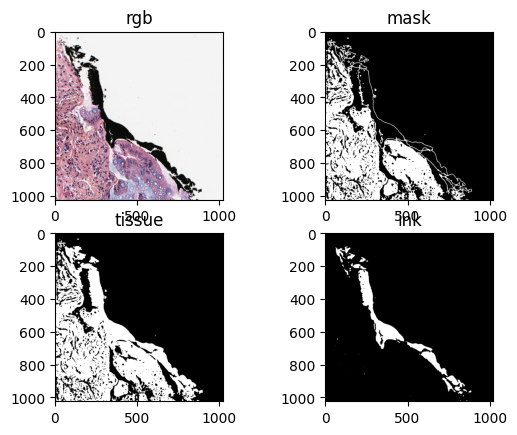

In [64]:
base_path = "/rsrch5/home/trans_mol_path/cercan/BE_master/0.input/flow/roi/flow/MDA12_ROI_patches_finetuning/train/D0050_ROI0.png"

img = cv2.imread(base_path)
plt.subplot(2, 2, 1)
plt.title('rgb')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)

img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img_blur = cv2.GaussianBlur(img_gray,(7,7),0)
_, mask_tissue = cv2.threshold(img_blur, 60, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)

# Plot the cropped image
plt.subplot(2, 2, 3)
plt.title('tissue')
plt.imshow(mask_tissue, cmap='gray')
# mask_tissue = 255 - mask_tissue

_, mask_ink = cv2.threshold(img_blur, 35, 255, cv2.THRESH_BINARY_INV)

# Plot the cropped image
plt.subplot(2, 2, 4)
plt.title('ink')
plt.imshow(mask_ink, cmap='gray')
# mask_ink = 255- mask_ink


mask = cv2.subtract(mask_tissue, mask_ink)
# mask = 255- mask



# Plot the cropped image
plt.subplot(2, 2, 2)
plt.title('mask')
plt.imshow(mask, cmap='gray')




# Show the plots
# plt.show()


In [65]:
mask = mask / 255
np.sum(mask) / mask.size

0.2674093246459961

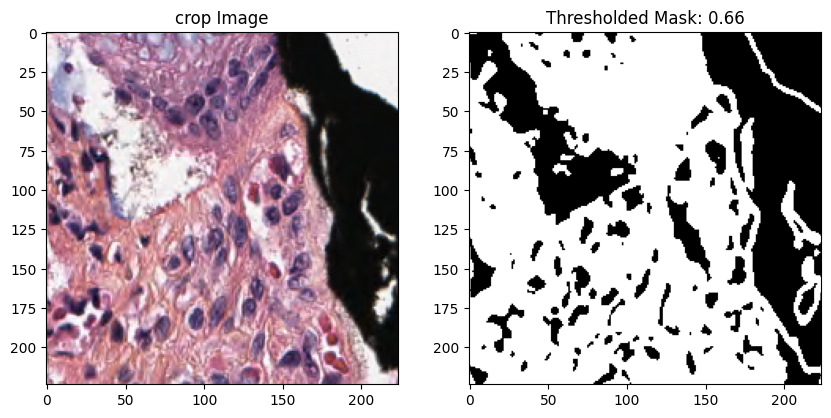

In [10]:
base_path = "/rsrch5/home/trans_mol_path/cercan/BE_master/0.input/flow/roi/flow/MDA12_ROI_patches_finetuning/train/D0050_ROI0.png"

img = cv2.imread(base_path)

img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img_blur = cv2.GaussianBlur(img_gray,(7,7),0)
# _, mask_tissue = cv2.threshold(img_blur, 60, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY)

_, mask_tissue = cv2.threshold(img_blur, 60, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)
_, mask_ink = cv2.threshold(img_blur, 30, 255, cv2.THRESH_BINARY_INV)
mask_foreground = cv2.subtract(mask_tissue, mask_ink)




# mask = cv2.subtract(mask_tissue, mask_ink)

img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
mask_tensor = tf.convert_to_tensor(mask_foreground, dtype=tf.float32)
mask_tensor = tf.expand_dims(mask_tensor, axis=-1)
mask_tensor = tf.tile(mask_tensor, [1, 1, 3])

stacked_image = tf.stack([img_tensor, mask_tensor], axis=0)

# 
# Apply random crop
crop_tensor = tf.image.random_crop(stacked_image, [2,224, 224, 3])

crop_img = crop_tensor[0]
crop_mask = crop_tensor[1]
# # Convert the tensor back to a NumPy array
crop_img = crop_img.numpy()
crop_img = np.clip(crop_img, 0, 255).astype(np.uint8)

crop_mask = crop_mask.numpy()
crop_mask = np.clip(crop_mask, 0, 255).astype(np.uint8)


crop_mask_01 = crop_mask / 255
tissue_percent = np.sum(crop_mask_01) / crop_mask_01.size

# # Ensure the pixel values are in the correct range for display

# cv2.imwrite('/rsrch5/home/trans_mol_path/cercan/BE_master/0.input/flow/roi/flow/MDA12_ROI_patches_finetuning/cropped_image.png', crop_img)
# cv2.imwrite('/rsrch5/home/trans_mol_path/cercan/BE_master/0.input/flow/roi/flow/MDA12_ROI_patches_finetuning/cropped_mask.png', crop_mask)


# Display the cropped image
# cv2.imshow('Image', crop)

# crop_tensor[0].shape


plt.figure(figsize=(10, 5))

# Plot the thresholded image
plt.subplot(1, 2, 1)
plt.title('crop Image')
plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))

# Plot the cropped image
plt.subplot(1, 2, 2)
plt.title(f'Thresholded Mask: {tissue_percent:.2f}')
plt.imshow(crop_mask, cmap='gray')



# # Plot the cropped image
# plt.subplot(2, 2, 3)
# plt.title('tissue')
# plt.imshow(mask_tissue, cmap='gray')
# # mask_tissue = 255 - mask_tissue


# # Plot the cropped image
# plt.subplot(2, 2, 4)
# plt.title('ink')
# plt.imshow(mask_ink, cmap='gray')


# Show the plots
plt.show()




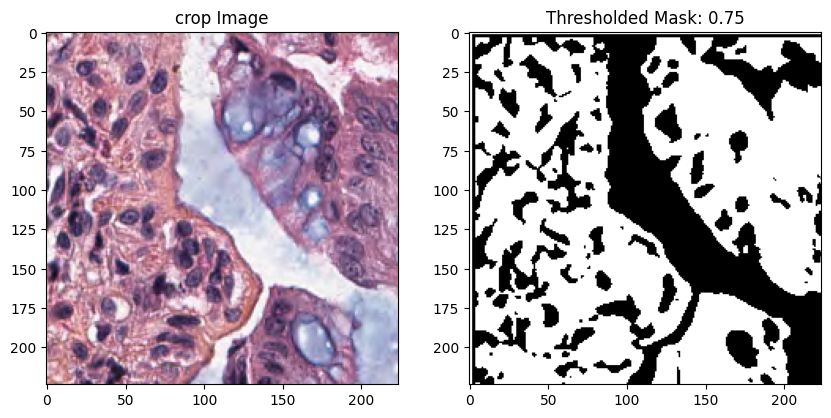

In [9]:


img_gray = cv2.cvtColor(crop_img, cv2.COLOR_RGB2GRAY)
img_blur = cv2.GaussianBlur(img_gray,(7,7),0)
_, mask_tissue = cv2.threshold(img_blur, 60, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)
mask_tissue = cv2.morphologyEx(mask_tissue, cv2.MORPH_CLOSE,  np.zeros((5, 5), np.uint8))

plt.figure(figsize=(10, 5))

# Plot the thresholded image
plt.subplot(1, 2, 1)
plt.title('crop Image')
plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))

# Plot the cropped image
plt.subplot(1, 2, 2)
plt.title(f'Thresholded Mask: {tissue_percent:.2f}')
plt.imshow(mask_tissue, cmap='gray')